# Current WebArena Example Analysis

This notebook is the current analysis surface for the local WebArena-Verified thesis prototype.

It covers all currently available example paths:

- Service probe: `shopping`, `shopping_admin`, `reddit`, `gitlab`, `wikipedia`
- Official hardcoded tasks: `shopping` 118, `shopping_admin` 157, `reddit` 27, `gitlab` 44
- Planner preview: all enabled local sites except Map
- H/k orchestrator: `gitlab` 44 and `shopping` 118

Important scope note: Reddit is executable and analyzable through the hardcoded retrieve task and planner preview. It is not yet part of the H/k orchestrator because no Reddit-specific Executor/Evaluator loop has been implemented yet.

In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

OFFICIAL_REPO = ROOT / 'external' / 'webarena-verified'
SWEEP_BASE = OFFICIAL_REPO / 'output' / 'hk-sweep'
SERVICE_SUMMARY = OFFICIAL_REPO / 'output' / 'service-probe' / 'summary.json'
HARDCODED_SUMMARY = OFFICIAL_REPO / 'output' / 'hardcoded-tasks' / 'summary.json'
PLANNER_PREVIEW_SUMMARY = OFFICIAL_REPO / 'output' / 'planner-preview' / 'summary.json'

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.max_columns', 80)
plt.style.use('seaborn-v0_8-whitegrid')

SITE_ORDER = ['shopping', 'shopping_admin', 'reddit', 'gitlab', 'wikipedia']
HK_SITE_ORDER = ['gitlab', 'shopping']

def read_json(path: Path):
    return json.loads(path.read_text())

def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    rows = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)

def show_bar(ax, values, title, ylabel=None, xlabel=None, ylim=None, color='#4c78a8'):
    values.plot(kind='bar', ax=ax, color=color, rot=35)
    ax.set_title(title)
    ax.set_ylabel(ylabel or '')
    ax.set_xlabel(xlabel or '')
    if ylim:
        ax.set_ylim(*ylim)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2g', padding=3)

ROOT, OFFICIAL_REPO

## Optional: Regenerate All Example Artifacts

Set `RUN_ALL_EXAMPLES = True` when you want this notebook to regenerate all current artifacts. This can take several minutes because the H/k and Planner-Preview cells call Ollama, BrowserGym, and the official WebArena-Verified evaluator.

In [2]:
RUN_ALL_EXAMPLES = False
MODEL = 'gemma4:26b'

COMMANDS = [
    ['uv', 'run', 'python', 'scripts/run_services_probe.py', '--sites', 'shopping', 'shopping_admin', 'reddit', 'gitlab', 'wikipedia'],
    ['uv', 'run', 'python', 'scripts/run_hardcoded_tasks.py', '--sites', 'shopping', 'shopping_admin', 'reddit', 'gitlab'],
    ['uv', 'run', 'python', 'scripts/preview_planner.py', '--planner-mode', 'ollama', '--model', MODEL, '--sites', 'shopping', 'shopping_admin', 'reddit', 'gitlab', 'wikipedia', '--h', '0'],
    ['uv', 'run', 'python', 'scripts/run_hk_sweep.py', '--site', 'gitlab', '--output-root', 'output/hk-sweep/gitlab', '--hs', '0', '1', '2', '--ks', '1', '2', '--model', MODEL],
    ['uv', 'run', 'python', 'scripts/run_hk_sweep.py', '--site', 'shopping', '--output-root', 'output/hk-sweep/shopping', '--hs', '0', '--ks', '1', '2', '--model', MODEL],
]

if RUN_ALL_EXAMPLES:
    for command in COMMANDS:
        print('$', ' '.join(command))
        subprocess.run(command, cwd=ROOT, check=True)
else:
    print('Execution skipped. Set RUN_ALL_EXAMPLES = True to regenerate all artifacts.')
    print('Commands available:')
    for command in COMMANDS:
        print(' ', ' '.join(command))

Execution skipped. Set RUN_ALL_EXAMPLES = True to regenerate all artifacts.
Commands available:
  uv run python scripts/run_services_probe.py --sites shopping shopping_admin reddit gitlab wikipedia
  uv run python scripts/run_hardcoded_tasks.py --sites shopping shopping_admin reddit gitlab
  uv run python scripts/preview_planner.py --planner-mode ollama --model gemma4:26b --sites shopping shopping_admin reddit gitlab wikipedia --h 0
  uv run python scripts/run_hk_sweep.py --site gitlab --output-root output/hk-sweep/gitlab --hs 0 1 2 --ks 1 2 --model gemma4:26b
  uv run python scripts/run_hk_sweep.py --site shopping --output-root output/hk-sweep/shopping --hs 0 --ks 1 2 --model gemma4:26b


## Load Current Artifacts

In [3]:
service_df = pd.DataFrame(read_json(SERVICE_SUMMARY).get('results', [])) if SERVICE_SUMMARY.exists() else pd.DataFrame()
hardcoded_df = pd.DataFrame(read_json(HARDCODED_SUMMARY).get('results', [])) if HARDCODED_SUMMARY.exists() else pd.DataFrame()
preview_df = pd.DataFrame(read_json(PLANNER_PREVIEW_SUMMARY).get('results', [])) if PLANNER_PREVIEW_SUMMARY.exists() else pd.DataFrame()

hk_rows = []
for path in sorted(SWEEP_BASE.glob('*/summary.json')):
    summary = read_json(path)
    for row in summary.get('rows', []):
        row = dict(row)
        row['summary_file'] = str(path)
        hk_rows.append(row)
hk_df = pd.DataFrame(hk_rows)
if not hk_df.empty:
    hk_df['runtime_s'] = hk_df['total_runtime_ms'] / 1000
    hk_df['score'] = pd.to_numeric(hk_df['score'], errors='coerce')
    hk_df['run_label'] = hk_df['site'] + ' H' + hk_df['h'].astype(str) + '/k' + hk_df['k'].astype(str)
    hk_df = hk_df.sort_values(['site', 'task_id', 'h', 'k']).reset_index(drop=True)

print('service rows:', len(service_df))
print('hardcoded rows:', len(hardcoded_df))
print('planner preview rows:', len(preview_df))
print('H/k rows:', len(hk_df))

service rows: 5
hardcoded rows: 4
planner preview rows: 5
H/k rows: 8


## Coverage Overview

This table shows which example path exists for each site. It is the quickest check that Reddit is represented, even though it is not yet an H/k orchestrator site.

,site,service_probe,hardcoded_official_task,planner_preview,hk_orchestrator
0,shopping,True,True,True,True
1,shopping_admin,True,True,True,False
2,reddit,True,True,True,False
3,gitlab,True,True,True,True
4,wikipedia,True,False,True,False


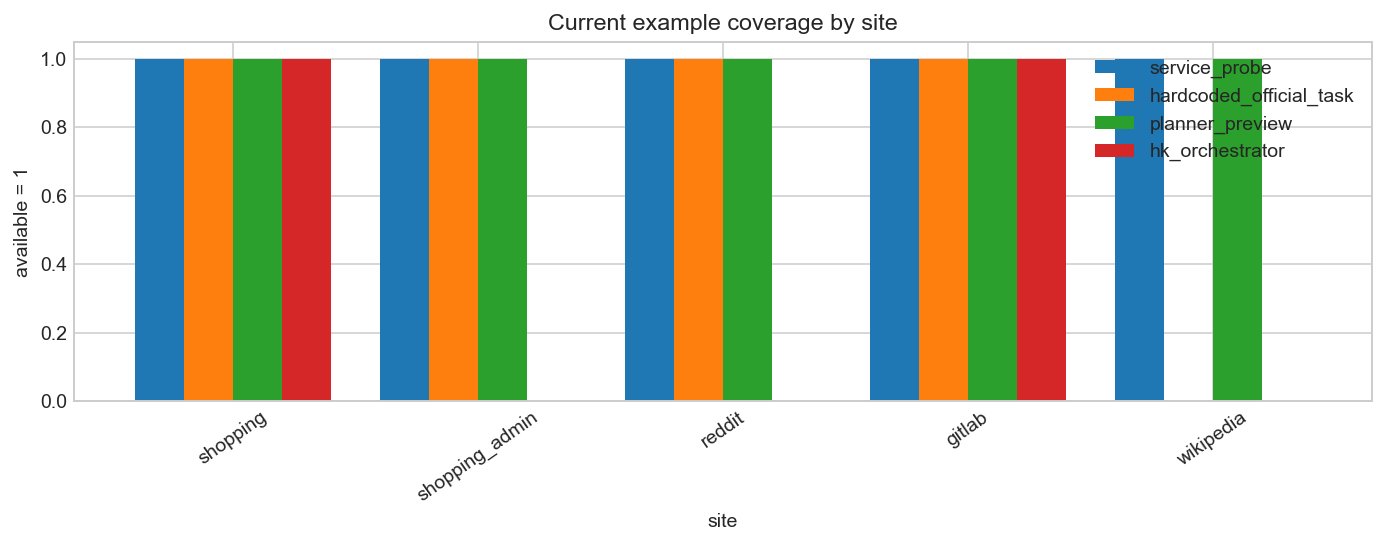

In [4]:
coverage = pd.DataFrame({'site': SITE_ORDER})
coverage['service_probe'] = coverage['site'].isin(service_df.get('site', pd.Series(dtype=str)))
coverage['hardcoded_official_task'] = coverage['site'].isin(hardcoded_df.get('site', pd.Series(dtype=str)))
coverage['planner_preview'] = coverage['site'].isin(preview_df.get('site', pd.Series(dtype=str)))
coverage['hk_orchestrator'] = coverage['site'].isin(hk_df.get('site', pd.Series(dtype=str)))
display(coverage)

plot_df = coverage.set_index('site').astype(int)
ax = plot_df.plot(kind='bar', figsize=(10, 4), rot=35, width=0.8)
ax.set_title('Current example coverage by site')
ax.set_ylabel('available = 1')
ax.set_xlabel('site')
ax.legend(loc='upper right')
plt.tight_layout()

## Service Probe Analysis

The service probe checks whether each local site can be opened through BrowserGym. It is not a task-solving evaluation.

,site,status,task_id,task_type,start_url,final_url,page_title,error
0,shopping,success,118.0,NAVIGATE,http://localhost:7770,http://localhost:7770/,One Stop Market,None
1,shopping_admin,success,157.0,NAVIGATE,http://localhost:7780/admin,http://localhost:7780/admin,Magento Admin,None
2,reddit,success,27.0,RETRIEVE,http://localhost:9999,http://localhost:9999/,Postmill,None
3,gitlab,success,44.0,NAVIGATE,http://localhost:8012,http://localhost:8012/users/sign_in,Sign in · GitLab,None
4,wikipedia,success,NaN,SERVICE_PROBE,http://localhost:8888,http://localhost:8888/wikipedia_en_all_maxi_2022-05/A/User:The_other_Kiwix_guy/Landing,User:The other Kiwix guy/Landing,None


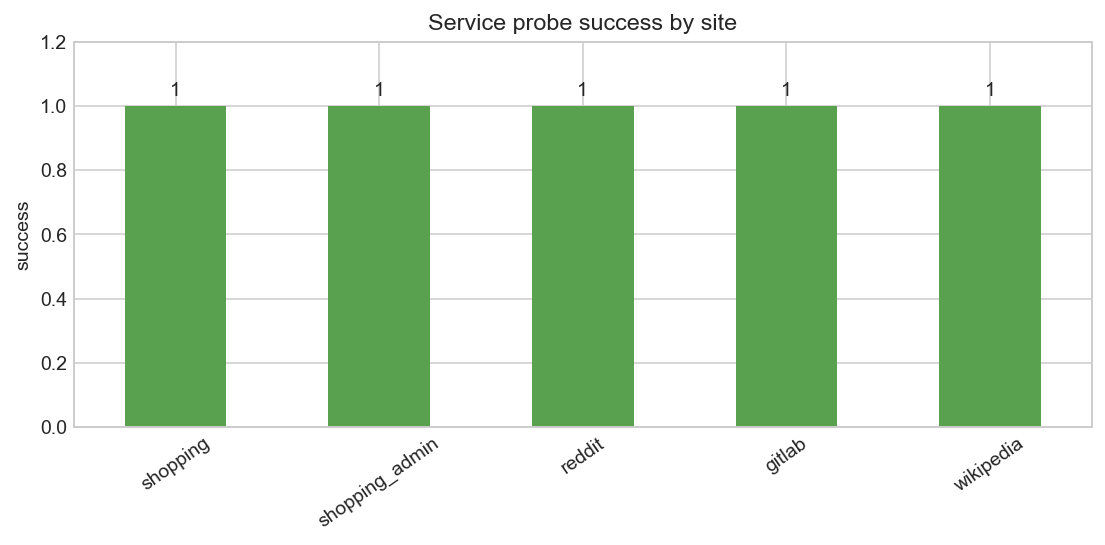

In [5]:
if service_df.empty:
    print('No service probe summary found:', SERVICE_SUMMARY)
else:
    service_cols = ['site', 'status', 'task_id', 'task_type', 'start_url', 'final_url', 'page_title', 'error']
    display(service_df[service_cols])
    service_plot = service_df.assign(success_flag=(service_df['status'] == 'success').astype(int)).set_index('site').reindex(SITE_ORDER)['success_flag']
    fig, ax = plt.subplots(figsize=(8, 4))
    show_bar(ax, service_plot, 'Service probe success by site', ylabel='success', ylim=(0, 1.2), color='#59a14f')
    plt.tight_layout()

## Official Hardcoded Task Analysis

These are deterministic task-solving examples with official WebArena-Verified evaluation. Reddit Task 27 is included here as a retrieve task.

,site,task_id,task_type,status,success,official_score,total_runtime_ms,browser_runtime_ms,official_eval_runtime_ms,final_url
0,shopping,118,NAVIGATE,success,True,1.0,5433,4771,661,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...
1,shopping_admin,157,NAVIGATE,success,True,1.0,10008,9365,642,http://localhost:7780/admin/customer/index/
2,reddit,27,RETRIEVE,success,True,1.0,4703,4069,632,http://localhost:9999/
3,gitlab,44,NAVIGATE,success,True,1.0,8811,8080,729,http://localhost:8012/dashboard/todos


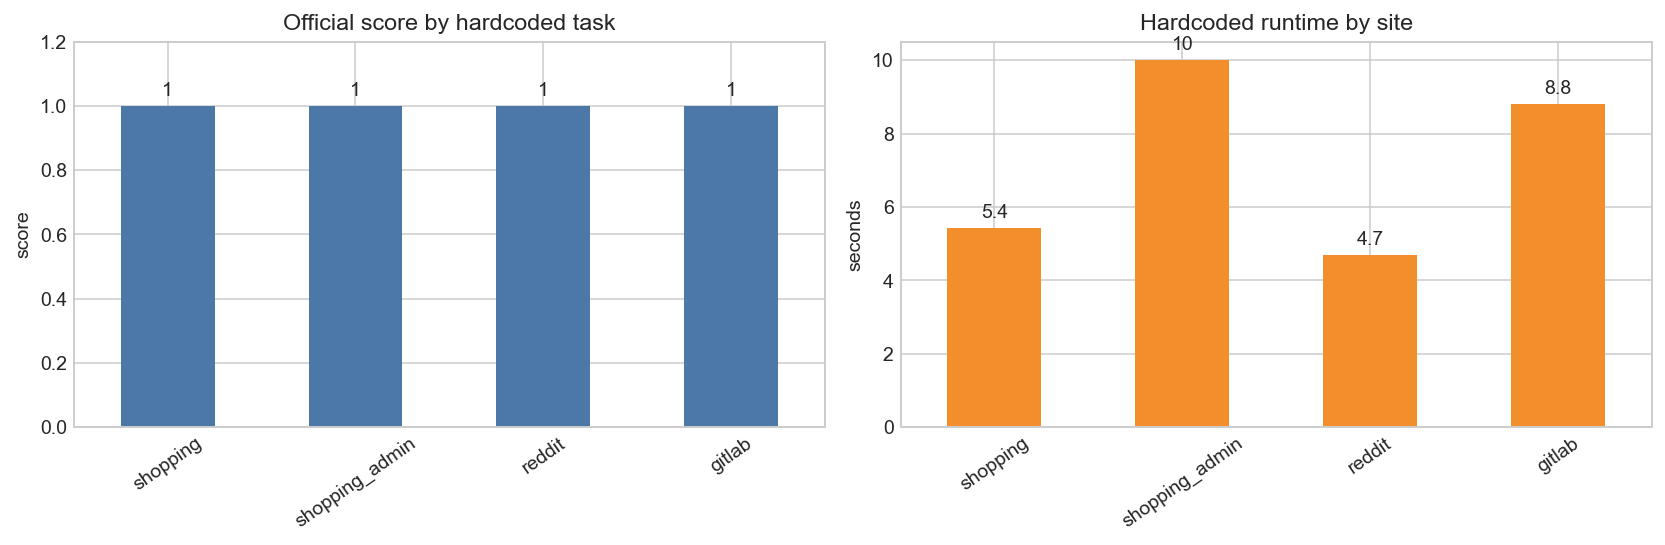

In [6]:
if hardcoded_df.empty:
    print('No hardcoded task summary found:', HARDCODED_SUMMARY)
else:
    hardcoded_cols = ['site', 'task_id', 'task_type', 'status', 'success', 'official_score', 'total_runtime_ms', 'browser_runtime_ms', 'official_eval_runtime_ms', 'final_url']
    display(hardcoded_df[hardcoded_cols])

    hardcoded_plot = hardcoded_df.set_index('site').reindex(['shopping', 'shopping_admin', 'reddit', 'gitlab'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    show_bar(axes[0], hardcoded_plot['official_score'], 'Official score by hardcoded task', ylabel='score', ylim=(0, 1.2), color='#4c78a8')
    show_bar(axes[1], hardcoded_plot['total_runtime_ms'] / 1000, 'Hardcoded runtime by site', ylabel='seconds', color='#f28e2b')
    plt.tight_layout()

## Planner Preview Analysis

Planner previews call the LLM planner and write plan artifacts, but they do not execute browser actions. This is where Reddit is visible as an LLM planning task before a full H/k executor exists.

,site,task_id,planner_mode,model_name,h,subgoal_count,warnings,output_dir
0,shopping,118.0,ollama,gemma4:26b,0,3,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/shopping/118
1,shopping_admin,157.0,ollama,gemma4:26b,0,3,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/shopping_admin/157
2,reddit,27.0,ollama,gemma4:26b,0,5,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/reddit/27
3,gitlab,44.0,ollama,gemma4:26b,0,2,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/gitlab/44
4,wikipedia,NaN,ollama,gemma4:26b,0,2,[],/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/planner-preview/wikipedia/direct


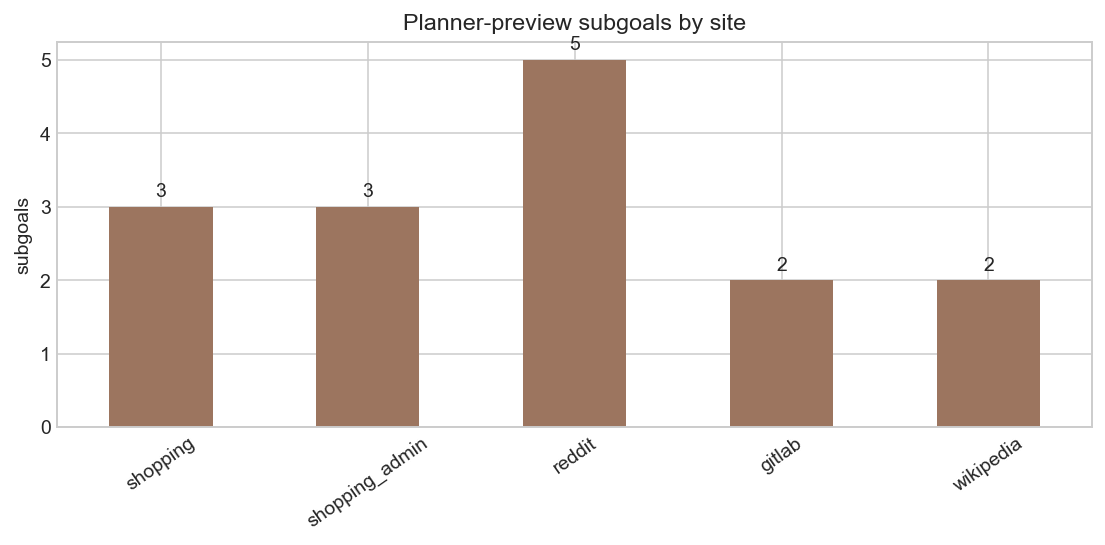

In [7]:
if preview_df.empty:
    print('No planner-preview summary found:', PLANNER_PREVIEW_SUMMARY)
else:
    preview_cols = ['site', 'task_id', 'planner_mode', 'model_name', 'h', 'subgoal_count', 'warnings', 'output_dir']
    display(preview_df[preview_cols])

    preview_plot = preview_df.set_index('site').reindex(SITE_ORDER)['subgoal_count']
    fig, ax = plt.subplots(figsize=(8, 4))
    show_bar(ax, preview_plot, 'Planner-preview subgoals by site', ylabel='subgoals', color='#9c755f')
    plt.tight_layout()

## H/k Orchestrator Analysis

The H/k orchestrator currently runs for GitLab Task 44 and Shopping Task 118. GitLab is the continuation-planning reference. Shopping is the first multi-action subgoal example where `k` visibly changes runtime evaluator frequency.

,site,task_id,h,k,score,success,total_steps,num_planner_calls,num_plan_subgoals_generated,total_tokens,runtime_s,output_dir
0,gitlab,44,0,1,1.0,True,2,1,2,1729,44.142,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h0_k1/44
1,gitlab,44,0,2,1.0,True,2,1,2,1978,34.199,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h0_k2/44
2,gitlab,44,1,1,1.0,True,2,2,2,4582,58.022,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h1_k1/44
3,gitlab,44,1,2,1.0,True,2,2,2,3979,56.731,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h1_k2/44
4,gitlab,44,2,1,1.0,True,2,1,2,1717,29.643,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h2_k1/44
5,gitlab,44,2,2,1.0,True,2,1,2,3130,67.989,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/gitlab/gemma4-26b/h2_k2/44
6,shopping,118,0,1,1.0,True,2,1,2,2094,38.638,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k1/118
7,shopping,118,0,2,1.0,True,2,1,2,1869,30.072,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k2/118


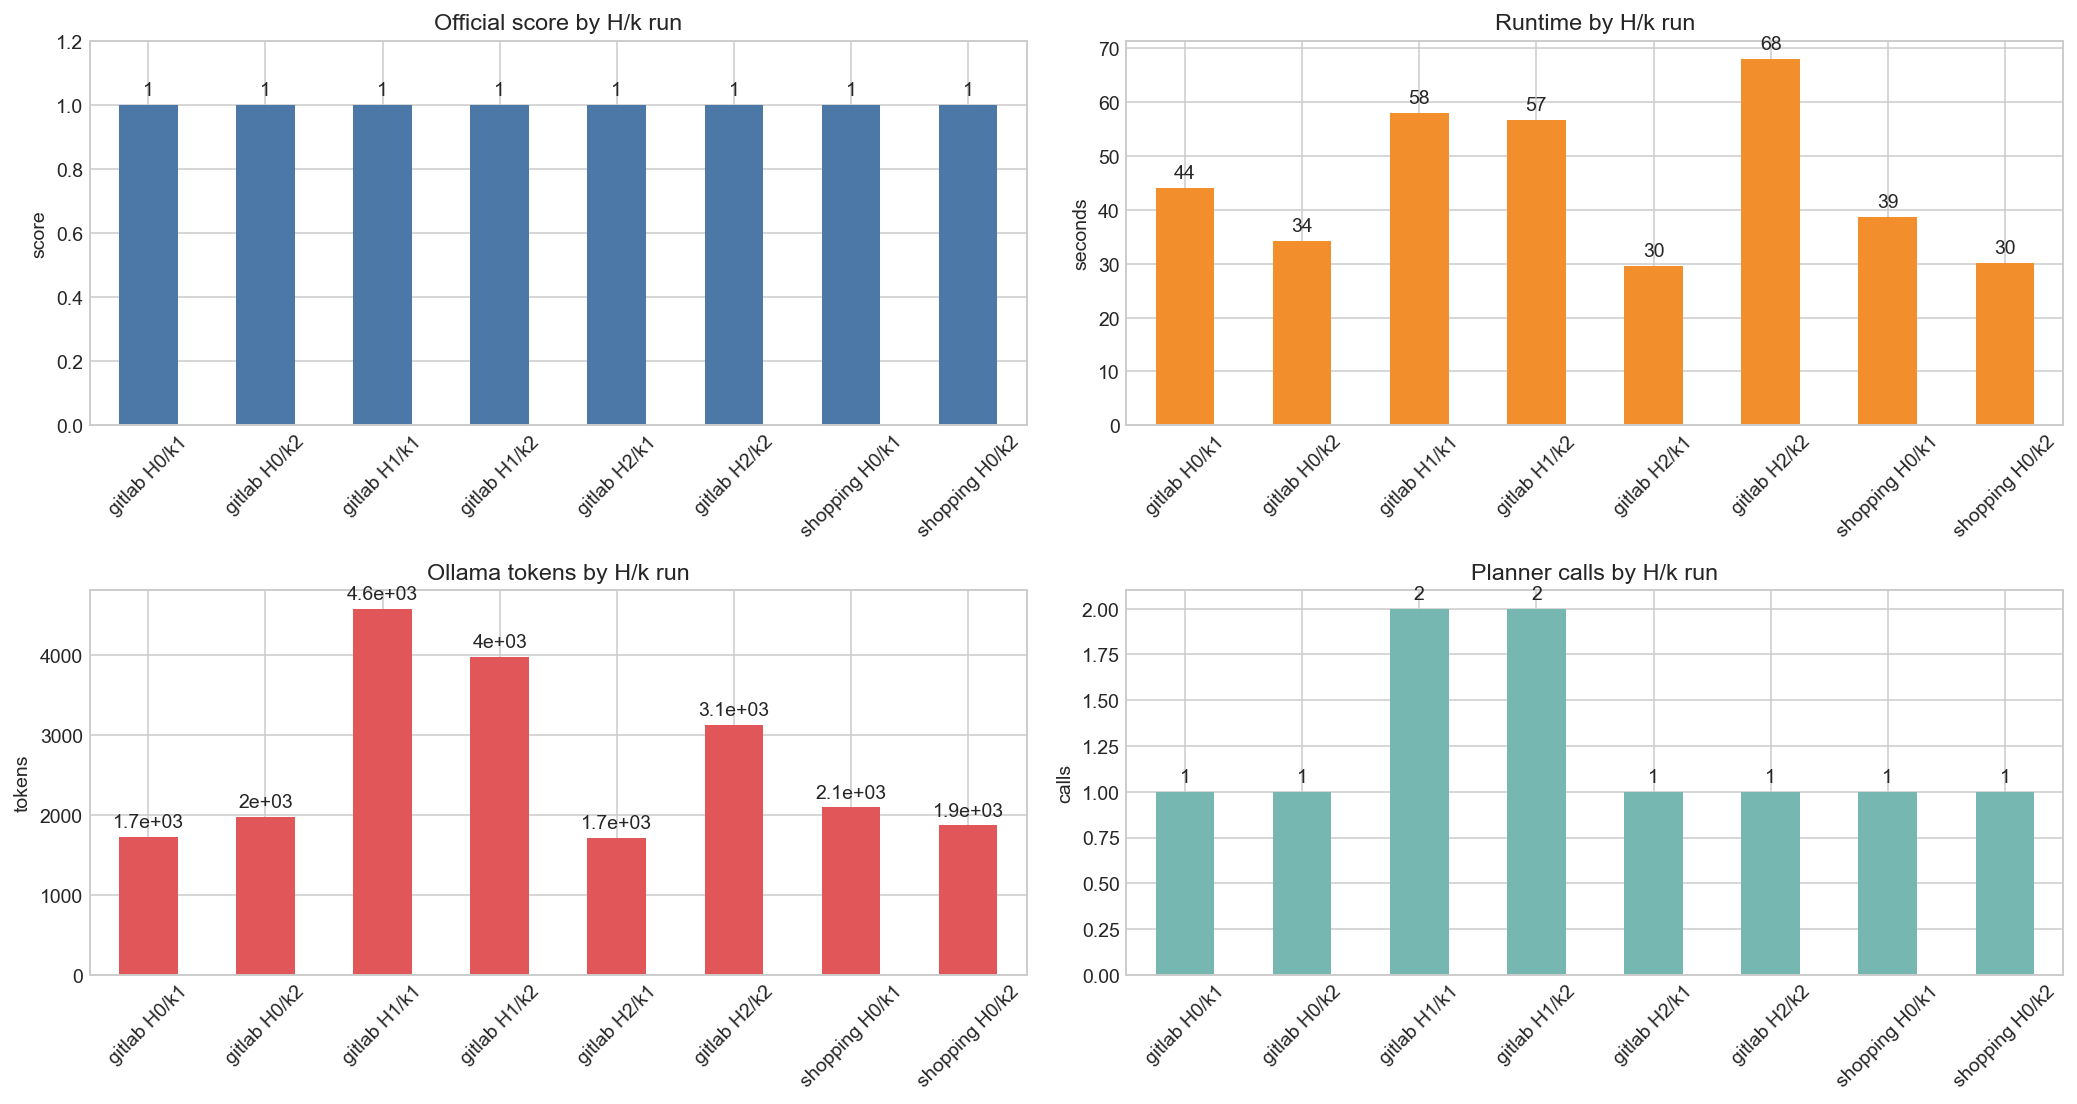

In [8]:
if hk_df.empty:
    print('No H/k sweep summaries found:', SWEEP_BASE)
else:
    hk_cols = ['site', 'task_id', 'h', 'k', 'score', 'success', 'total_steps', 'num_planner_calls', 'num_plan_subgoals_generated', 'total_tokens', 'runtime_s', 'output_dir']
    display(hk_df[hk_cols])

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    score_series = hk_df.set_index('run_label')['score']
    runtime_series = hk_df.set_index('run_label')['runtime_s']
    token_series = hk_df.set_index('run_label')['total_tokens']
    planner_series = hk_df.set_index('run_label')['num_planner_calls']
    show_bar(axes[0, 0], score_series, 'Official score by H/k run', ylabel='score', ylim=(0, 1.2), color='#4c78a8')
    show_bar(axes[0, 1], runtime_series, 'Runtime by H/k run', ylabel='seconds', color='#f28e2b')
    show_bar(axes[1, 0], token_series, 'Ollama tokens by H/k run', ylabel='tokens', color='#e15759')
    show_bar(axes[1, 1], planner_series, 'Planner calls by H/k run', ylabel='calls', color='#76b7b2')
    for ax in axes.ravel():
        ax.tick_params(axis='x', labelrotation=45)
    plt.tight_layout()

## H/k GitLab Detail

,h,k,score,total_steps,num_planner_calls,total_tokens,runtime_s
0,0,1,1.0,2,1,1729,44.142
1,0,2,1.0,2,1,1978,34.199
2,1,1,1.0,2,2,4582,58.022
3,1,2,1.0,2,2,3979,56.731
4,2,1,1.0,2,1,1717,29.643
5,2,2,1.0,2,1,3130,67.989


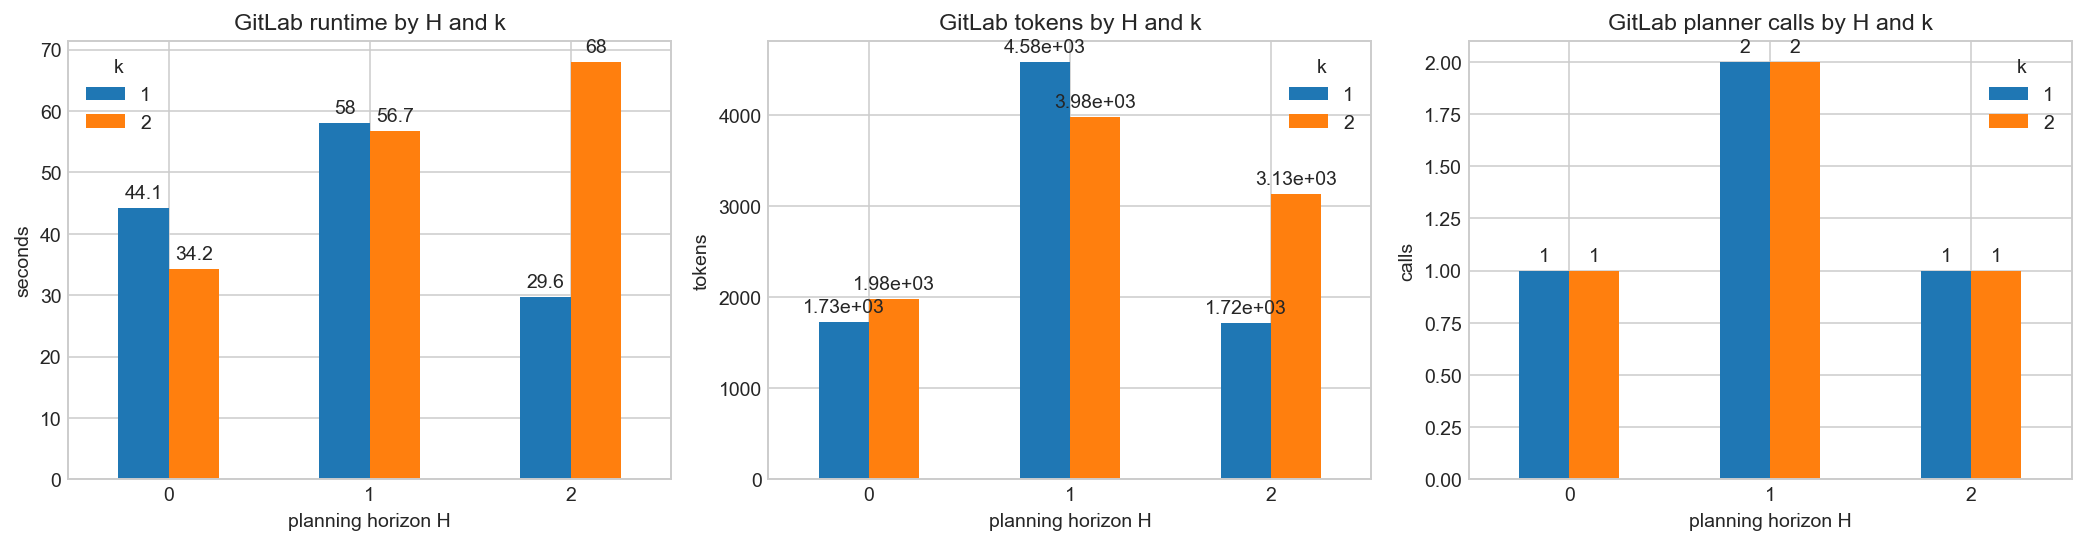

In [9]:
if not hk_df.empty and 'gitlab' in set(hk_df['site']):
    gitlab_df = hk_df[hk_df['site'] == 'gitlab'].copy()
    display(gitlab_df[['h', 'k', 'score', 'total_steps', 'num_planner_calls', 'total_tokens', 'runtime_s']])

    pivot_runtime = gitlab_df.pivot(index='h', columns='k', values='runtime_s')
    pivot_tokens = gitlab_df.pivot(index='h', columns='k', values='total_tokens')
    pivot_calls = gitlab_df.pivot(index='h', columns='k', values='num_planner_calls')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    pivot_runtime.plot(kind='bar', ax=axes[0], rot=0)
    axes[0].set_title('GitLab runtime by H and k')
    axes[0].set_ylabel('seconds')
    pivot_tokens.plot(kind='bar', ax=axes[1], rot=0)
    axes[1].set_title('GitLab tokens by H and k')
    axes[1].set_ylabel('tokens')
    pivot_calls.plot(kind='bar', ax=axes[2], rot=0)
    axes[2].set_title('GitLab planner calls by H and k')
    axes[2].set_ylabel('calls')
    for ax in axes:
        ax.set_xlabel('planning horizon H')
        ax.legend(title='k')
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3g', padding=3)
    plt.tight_layout()

## H/k Shopping Detail: k As Action-Level Validation

Shopping Task 118 executes two concrete browser actions for one product-finding subgoal. `k=1` produces an intermediate evaluator signal at the search page; `k=2` waits until the product page.

Shopping H0/k1 step trace
Shopping H0/k1 evaluator signals
Shopping H0/k2 step trace
Shopping H0/k2 evaluator signals


,h,k,score,total_steps,num_planner_calls,total_tokens,runtime_s,output_dir
6,0,1,1.0,2,1,2094,38.638,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k1/118
7,0,2,1.0,2,1,1869,30.072,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified/output/hk-sweep/shopping/gemma4-26b/h0_k2/118


,step_index,subgoal_id,action,url_before,url_after,status
0,0,sg1,env.reset,NaN,http://localhost:7770/,success
1,1,sg1,"goto(""http://localhost:7770/catalogsearch/result/?q=mouth+guard"")",http://localhost:7770/,http://localhost:7770/catalogsearch/result/?q=mouth+guard,success
2,2,sg1,"goto(""http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-s...",http://localhost:7770/catalogsearch/result/?q=mouth+guard,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...,success


,step_index,subgoal_id,progress_score,subgoal_done,reason,recommended_intervention
0,1,sg1,0.5,False,shopping_search_results_reached,continue
1,2,sg1,1.0,True,target_product_page_reached,continue


,step_index,subgoal_id,action,url_before,url_after,status
0,0,sg1,env.reset,NaN,http://localhost:7770/,success
1,1,sg1,"goto(""http://localhost:7770/catalogsearch/result/?q=mouth+guard"")",http://localhost:7770/,http://localhost:7770/catalogsearch/result/?q=mouth+guard,success
2,2,sg1,"goto(""http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-s...",http://localhost:7770/catalogsearch/result/?q=mouth+guard,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...,success


,step_index,subgoal_id,progress_score,subgoal_done,reason,recommended_intervention
0,2,sg1,1.0,True,target_product_page_reached,continue


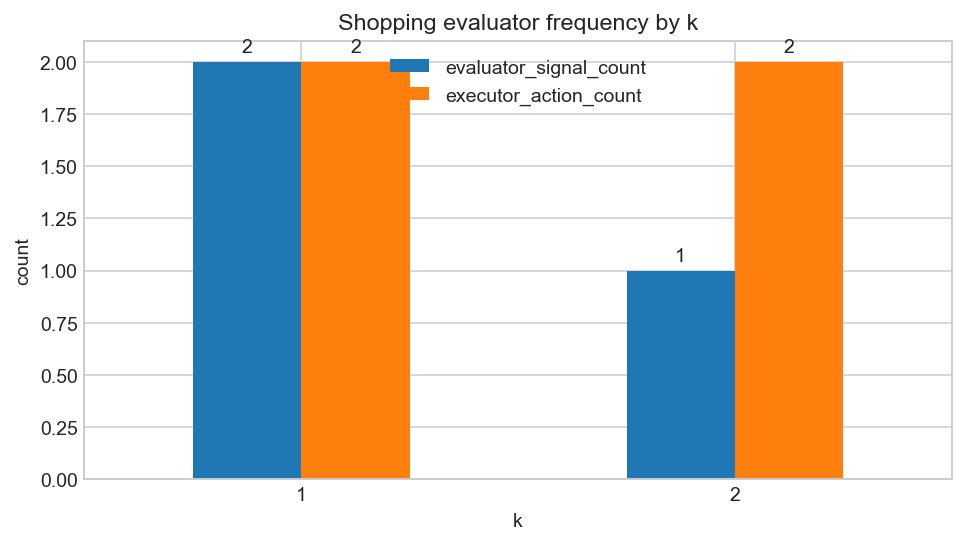

In [10]:
def artifact_paths(output_dir: str) -> dict[str, Path]:
    base = Path(output_dir)
    return {
        'plan': base / 'plan.json',
        'step_trace': base / 'step_trace.jsonl',
        'evaluator_signals': base / 'evaluator_signals.jsonl',
        'controller_decisions': base / 'controller_decisions.jsonl',
        'run_summary': base / 'run_summary.json',
        'eval_result': base / 'eval_result.json',
    }

if not hk_df.empty and 'shopping' in set(hk_df['site']):
    shopping_df = hk_df[hk_df['site'] == 'shopping'].copy()
    display(shopping_df[['h', 'k', 'score', 'total_steps', 'num_planner_calls', 'total_tokens', 'runtime_s', 'output_dir']])

    signal_rows = []
    for _, row in shopping_df.iterrows():
        signals = read_jsonl(artifact_paths(row['output_dir'])['evaluator_signals'])
        steps = read_jsonl(artifact_paths(row['output_dir'])['step_trace'])
        signal_rows.append({'k': row['k'], 'evaluator_signal_count': len(signals), 'executor_action_count': max(len(steps) - 1, 0)})
        print(f"Shopping H{row['h']}/k{row['k']} step trace")
        display(steps[['step_index', 'subgoal_id', 'action', 'url_before', 'url_after', 'status']])
        print(f"Shopping H{row['h']}/k{row['k']} evaluator signals")
        display(signals[['step_index', 'subgoal_id', 'progress_score', 'subgoal_done', 'reason', 'recommended_intervention']])

    signal_df = pd.DataFrame(signal_rows).set_index('k').sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    signal_df.plot(kind='bar', ax=ax, rot=0)
    ax.set_title('Shopping evaluator frequency by k')
    ax.set_xlabel('k')
    ax.set_ylabel('count')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3)
    plt.tight_layout()

## Interpretation Snapshot

In [11]:
checks = {
    'service_probe_all_success': bool(not service_df.empty and (service_df['status'] == 'success').all()),
    'hardcoded_all_official_score_1': bool(not hardcoded_df.empty and (hardcoded_df['official_score'] == 1.0).all()),
    'planner_preview_all_sites_present': set(SITE_ORDER).issubset(set(preview_df.get('site', []))),
    'hk_all_official_score_1': bool(not hk_df.empty and (hk_df['score'] == 1.0).all()),
    'reddit_analyzable_via_hardcoded': 'reddit' in set(hardcoded_df.get('site', [])),
    'reddit_analyzable_via_planner_preview': 'reddit' in set(preview_df.get('site', [])),
}
for key, value in checks.items():
    print(f'{key}: {value}')

service_probe_all_success: True
hardcoded_all_official_score_1: True
planner_preview_all_sites_present: True
hk_all_official_score_1: True
reddit_analyzable_via_hardcoded: True
reddit_analyzable_via_planner_preview: True
